## **Problem 4: Titanic Survival Prediction**

In [93]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

from mlxtend.plotting import plot_decision_regions

In [56]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [57]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [58]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
df['Cabin'] = df['Cabin'].fillna("Missing")

df['Deck'] = df['Cabin'].astype(str).str[0]

df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Deck
257,258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5000,B77,S,1,B
301,302,1,3,"McCoy, Mr. Bernard",male,NaN,2,0,367226,23.2500,Missing,Q,3,M
120,121,0,2,"Hickman, Mr. Stanley George",male,21.0,2,0,S.O.C. 14879,73.5000,Missing,S,3,M
57,58,0,3,"Novel, Mr. Mansouer",male,28.5,0,0,2697,7.2292,Missing,C,1,M
250,251,0,3,"Reed, Mr. James George",male,NaN,0,0,362316,7.2500,Missing,S,1,M


In [59]:
X = df.drop(['Survived', 'Name'], axis=1)
y = df['Survived']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [61]:
#age
mean_age = X_train['Age'].mean()
std_age = X_train['Age'].std()

X_train['Z_score'] = (X_train['Age'] - mean_age) / std_age

musk = (abs(X_train['Z_score']) <= 3)

X_train = X_train[musk]
y_train = y_train[musk]

# fare

fare_Q1 = X_train['Fare'].quantile(0.25)
fare_Q3 = X_train['Fare'].quantile(0.75)

IQR = fare_Q3 - fare_Q1

minimum = max(0 , fare_Q1 - 1.5 * IQR)
maximum = fare_Q3 + 1.5 * IQR

X_train['Fare'] = X_train['Fare'].clip(minimum, maximum)

In [62]:
# pipeline

# numerical
p1 = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='mean')),
        ('scaler',StandardScaler())
    ]
)

p2 = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',MinMaxScaler())
    ]
)

In [68]:
# categories = [[3, 2, 1]]# categories goes one after another via stricly following the order of the input
categories = [['third','second','first']]

In [69]:

# pipeline

#  categorical columns

p3 = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
    ]
)

# p4 = Pipeline(
#     steps=[
#         ('imputer',SimpleImputer(strategy='most_frequent')),
#         ('encoder',OrdinalEncoder(categories=categories)),
#         ('scaler',MinMaxScaler())
#     ]
# )

In [73]:
preprocessor = ColumnTransformer(
    transformers=[
        ('pipeline_1',p1,['Age']),
        ('pipeline_2',p2,['Fare','Family_Size', 'Pclass']),
        ('pipeline_3',p3,['Embarked','Sex','Deck']),
        # ('pipeline_4',p4,['Pclass'])
    ],
    remainder='drop'
)
preprocessor

ColumnTransformer(transformers=[('pipeline_1',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Age']),
                                ('pipeline_2',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', MinMaxScaler())]),
                                 ['Fare', 'Family_Size', 'Pclass']),
                                ('pipeline_3',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Embarked', 'Sex', 'Deck'])])

In [74]:
le = LabelEncoder()

le.fit(y_train)

y_train = le.transform(y_train)
y_test = le.transform(y_test)



In [75]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77       110
           1       0.63      0.58      0.61        69

    accuracy                           0.71       179
   macro avg       0.69      0.69      0.69       179
weighted avg       0.71      0.71      0.71       179



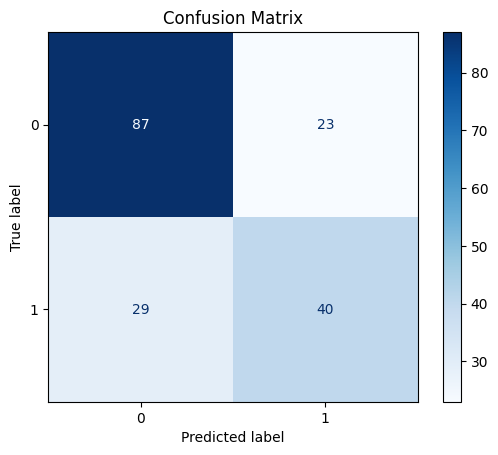

In [80]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [84]:
# Feature names after preprocessing
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Feature importance
importance = model.named_steps['classifier'].feature_importances_

# DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                    Feature  Importance
6      pipeline_3__Sex_male    0.298606
0           pipeline_1__Age    0.291794
1          pipeline_2__Fare    0.200495
3        pipeline_2__Pclass    0.096272
13       pipeline_3__Deck_M    0.044049
2   pipeline_2__Family_Size    0.032276
8        pipeline_3__Deck_C    0.012811
4    pipeline_3__Embarked_Q    0.007089
9        pipeline_3__Deck_D    0.006626
5    pipeline_3__Embarked_S    0.005641
12       pipeline_3__Deck_G    0.003720
7        pipeline_3__Deck_B    0.000620
10       pipeline_3__Deck_E    0.000000
11       pipeline_3__Deck_F    0.000000
14       pipeline_3__Deck_T    0.000000


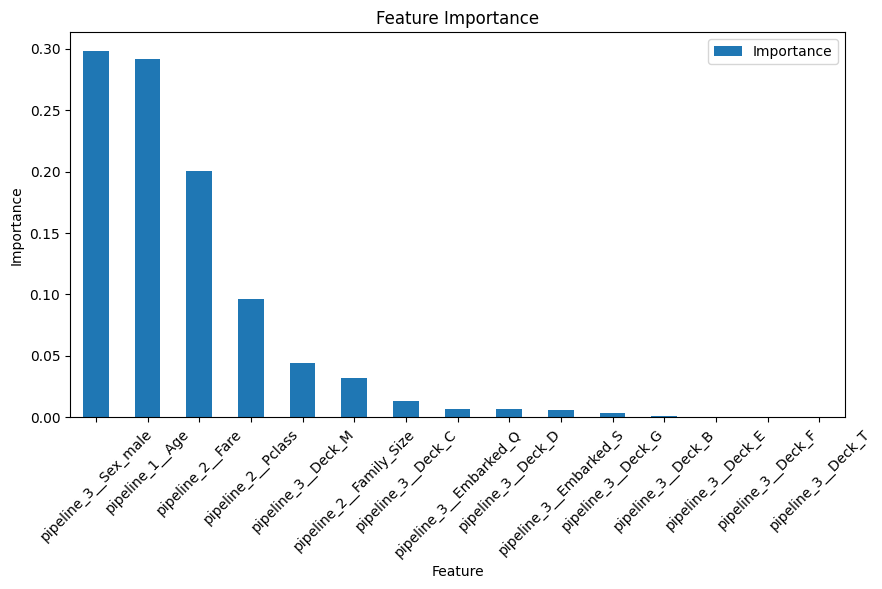

In [86]:
feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

## **Problem 5: Iris Dataset**

In [103]:
from sklearn.datasets import load_iris
from sklearn import datasets

In [104]:
iris = datasets.load_iris()

In [106]:
X = iris.data[:, [2,3]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [107]:
model = DecisionTreeClassifier()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [114]:
# tree

tree = DecisionTreeClassifier(criterion='entropy',
                              max_depth = 2,
                              random_state = 42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)

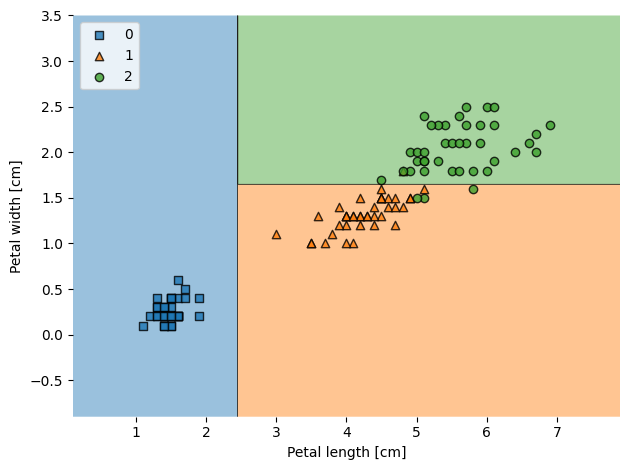

In [115]:
plot_decision_regions(X_train, y_train, tree)

plt.xlabel("Petal length [cm]")
plt.ylabel("Petal width [cm]")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()